In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\data.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (500, 12)

First 5 Rows:
   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030           1.0            3.0         3.0      1967.0   
1   2   287.678577           1.0            2.0         1.0      1949.0   
2   3   232.998485           1.0            3.0         2.0      1923.0   
3   4   199.664621           5.0            2.0         2.0      1918.0   
4   5    89.004660           4.0            3.0         3.0      1999.0   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0         1.0       1.0         48.0        8.297631            5.935734   
1         0.0       1.0         37.0        6.061466           10.827392   
2         1.0       0.0         14.0        2.911442            6.904599   
3         0.0       0.0         17.0        2.070949            8.284019   
4         1.0       0.0         34.0        1.523278           14.648277   

   Price  
0   6021  
1   5914  
2   4645  
3   5831

In [5]:
#removing duplicates
df = df.drop_duplicates()
#filling missing values with mean
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

#removing id column
df = df.drop("ID", axis=1)

print("\nDataset Shape After Cleaning:", df.shape)


Dataset Shape After Cleaning: (500, 11)



Summary Statistics:
       Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors   Year_Built  \
count   500.000000    500.000000     500.000000  500.000000   500.000000   
mean    174.568172      2.955466       1.977956    1.963783  1957.734940   
std      74.575885      1.433230       0.819058    0.799985    35.398873   
min      51.265396      1.000000       1.000000    1.000000  1900.000000   
25%     110.319923      2.000000       1.000000    1.000000  1926.750000   
50%     177.414749      3.000000       2.000000    2.000000  1959.000000   
75%     239.031220      4.000000       3.000000    3.000000  1988.000000   
max     298.241199      5.000000       3.000000    3.000000  2022.000000   

       Has_Garden    Has_Pool  Garage_Size  Location_Score  \
count  500.000000  500.000000   500.000000      500.000000   
mean     0.536437    0.490982    30.225806        5.156770   
std      0.496166    0.499919    11.489710        2.848370   
min      0.000000    0.000000    10.000000    

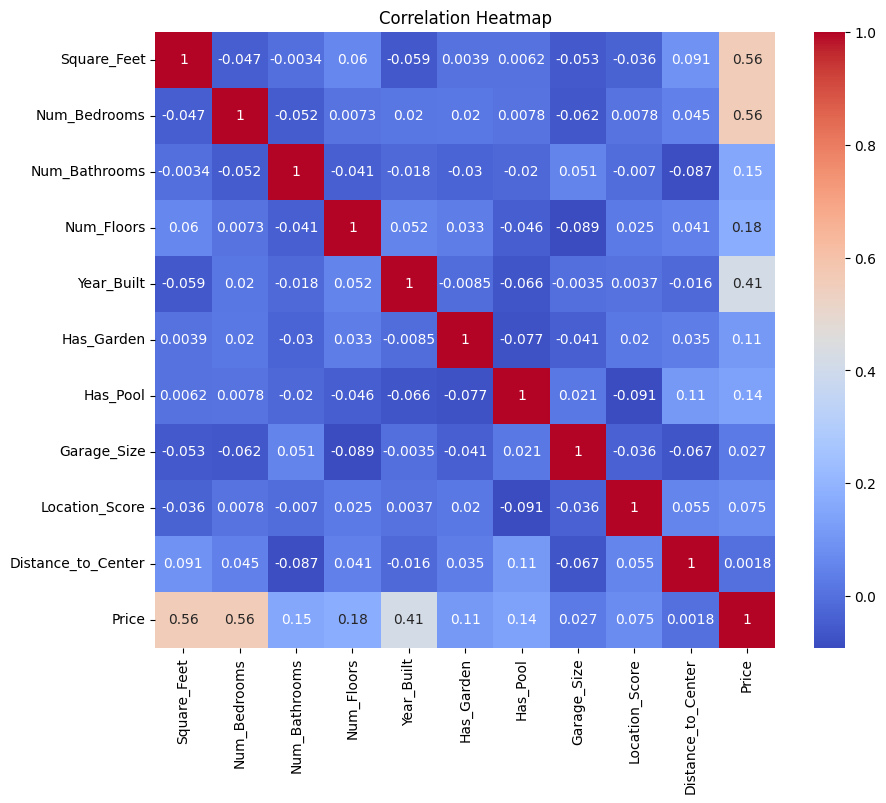

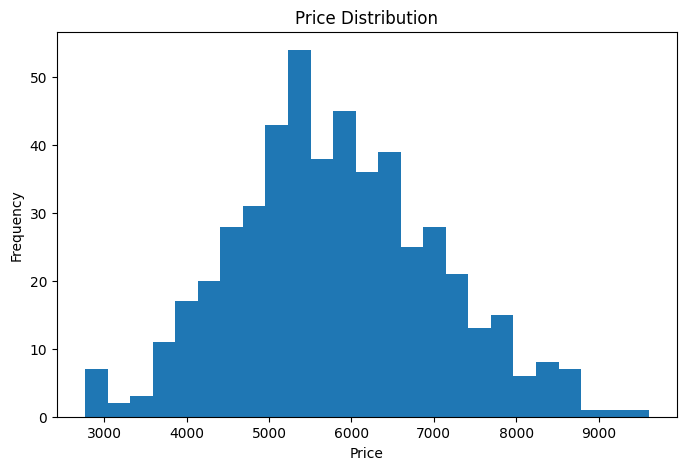

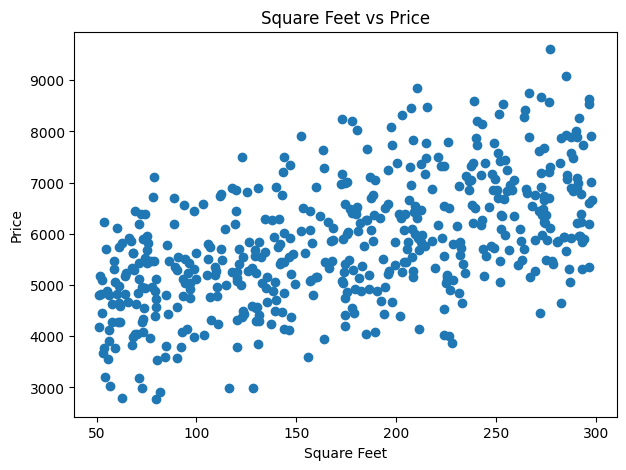

In [6]:
#data analysis

print("\nSummary Statistics:")
print(df.describe())

#correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#price Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=25)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#square feet vs price
plt.figure(figsize=(7,5))
plt.scatter(df["Square_Feet"], df["Price"])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Square Feet vs Price")
plt.show()

In [8]:
#train-test(80-20)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.8 * len(df))

train_df = df[:train_size]
test_df = df[train_size:]

X_train = train_df.drop("Price", axis=1).values
y_train = train_df["Price"].values.reshape(-1,1)

X_test = test_df.drop("Price", axis=1).values
y_test = test_df["Price"].values.reshape(-1,1)

X_train = np.c_[np.ones((X_train.shape[0],1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0],1)), X_test]

In [9]:
beta = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train

print("\nRegression Coefficients:")
print(beta)

y_pred = X_test @ beta

residuals = y_test - y_pred

RSS = np.sum(residuals**2)
MSE = np.mean(residuals**2)

print("\nModel Performance")
print("------------------")
print("RSS =", RSS)
print("MSE =", MSE)


Regression Coefficients:
[[-2.92511256e+04]
 [ 1.00645009e+01]
 [ 5.08253404e+02]
 [ 2.97199948e+02]
 [ 2.13573642e+02]
 [ 1.53664552e+01]
 [ 3.03752468e+02]
 [ 4.74576722e+02]
 [ 9.69937596e+00]
 [ 4.72164835e+01]
 [-1.98271780e+01]]

Model Performance
------------------
RSS = 4628296.972070238
MSE = 46282.96972070238


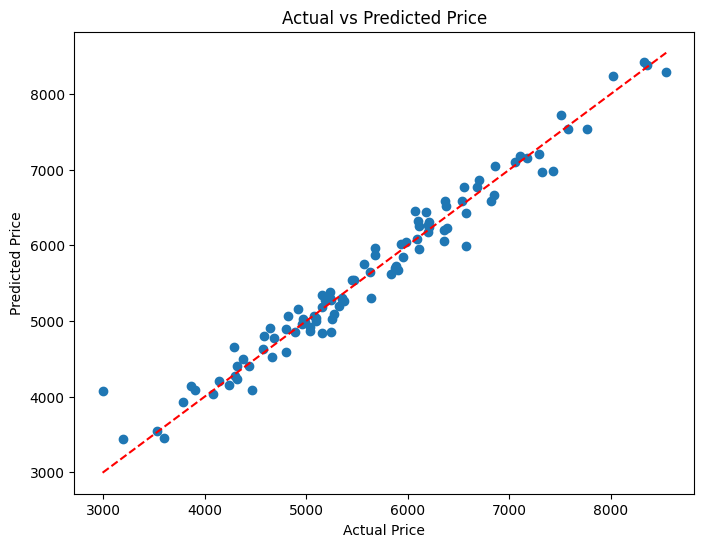

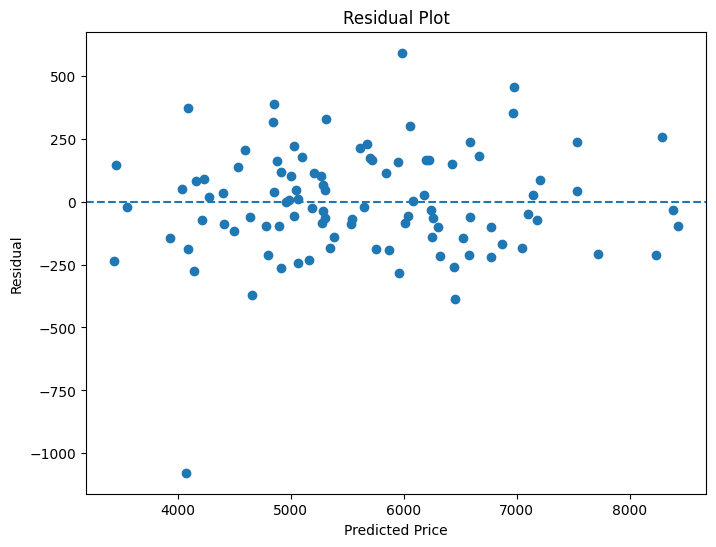

In [11]:
#comparison of actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

#residual plot
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [12]:
print("\nInterpretation")
print("--------------")
print(f"Residual Sum of Squares (RSS): {RSS:.2f}")
print(f"Mean Squared Error (MSE): {MSE:.2f}")

if MSE < 100000:
    print("The model predicts house prices with relatively low error.")
else:
    print("The prediction error is relatively high and the model may need improvement.")


Interpretation
--------------
Residual Sum of Squares (RSS): 4628296.97
Mean Squared Error (MSE): 46282.97
The model predicts house prices with relatively low error.
